
# TP - DLA - Privacy attacks (I) - Membership Inference

The goal of this practical session is to implement two simple privacy attacks on a simple network.
In this notebook, we focus on the membership inference attack.

## Training the model

In this cell, we provide the code for training a simple MLP model, trained for only 15 epochs on 500 samples.

In [67]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

from sklearn.metrics import RocCurveDisplay
from scipy.stats import gaussian_kde

# -------------------------------
# Load MNIST Data
# -------------------------------
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Use only 500 training samples (force overfitting, poor generalization)
subset_indices = list(range(1000))
train_subset = Subset(train_dataset, subset_indices)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# -------------------------------
# Small model
# -------------------------------
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)   # raw logits

model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -------------------------------
# Train the Model
# -------------------------------
def train(model, loader, optimizer, epochs=15):
    model.train()
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        for data, target in loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} completed")

train(model, train_loader, optimizer, epochs=15)




Epoch 5/15 completed
Epoch 10/15 completed
Epoch 15/15 completed


# Confidence evaluation


In [68]:
# -------------------------------
# Collect Confidences
# -------------------------------
def get_confidences(loader):
    model.eval()
    confs = []
    with torch.no_grad():
        for data, _ in loader:
            output = model(data)
            probs = F.softmax(output, dim=1)
            max_probs, _ = torch.max(probs, dim=1)
            confs.extend(max_probs.numpy())
    return np.array(confs)

train_confs = get_confidences(train_loader)
test_confs = get_confidences(test_loader)

# -------------------------------
# Print Summary Statistics
# -------------------------------
print("\n=== Confidence Summary ===")
print(f"Train mean confidence: {train_confs.mean():.3f}")
print(f"Test  mean confidence: {test_confs.mean():.3f}")




=== Confidence Summary ===
Train mean confidence: 0.919
Test  mean confidence: 0.867


# ROC curve
In order to evaluate the attack, plot the ROC curve (considering the train samples as one class and the test samples as the other class) and compute the AUC.

In [69]:
label=np.concat([np.ones(len(train_subset)),np.zeros(len(test_dataset))])
score=np.concat([train_confs,test_confs])

In [70]:
fpr, tpr, thresholds=roc_curve(label,score)

In [71]:
auccc=auc(fpr,tpr)
auccc

0.5841867

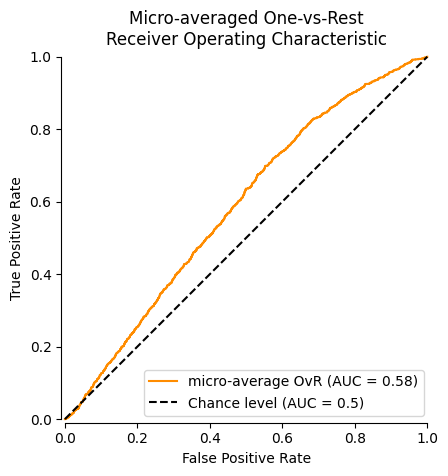

In [72]:

display = RocCurveDisplay.from_predictions(
    label.ravel(),
    score.ravel(),
    name="micro-average OvR",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Micro-averaged One-vs-Rest\nReceiver Operating Characteristic",
)


# Density estimation  

Using the gaussian KDE on both train and tests confidences, plot the estimated distributions.

Note that histograms can also be used (but are sometimes less clear).

In [ ]:

kde_train=gaussian_kde(train_confs)
kde_test=gaussian_kde(test_confs)

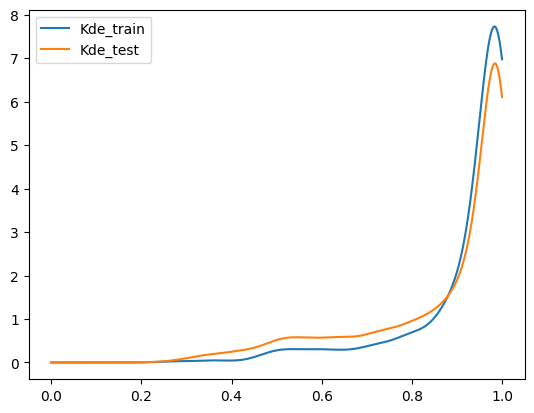

In [83]:
xs=np.linspace(0,1,1000)
plt.plot(xs,kde_train(xs),label="Kde_train")
plt.plot(xs,kde_test(xs),label="Kde_test")
plt.legend()
plt.show()

# Going further

Evaluate the impact on the attack when
- changing the number of trials used for training the MLP
- changing the number of epochs for training the MLP
- the architecture / optimize / regularization
- all at once